In [47]:
from helper_functions import wrangle, make_predictions
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

In [48]:
df = wrangle("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null 

## split

In [49]:
target = "Churn"
X = df.drop(columns=target)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 19)
y_train shape: (5625,)
X_test shape: (1407, 19)
y_test shape: (1407,)


## Resample

In [51]:
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train,y_train)
print(X_train_under.shape)
X_train_under.head()

(2990, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
customerID,,,,,,,,,,,,,,,,,,,
1904-WAJAA,Female,0,1,1,24,1,Yes,DSL,Yes,Yes,Yes,No,No,No,Two year,0,Electronic check,64.35,1558.65
6685-GBWJZ,Male,0,1,0,63,1,No,DSL,Yes,Yes,No,Yes,Yes,No,One year,0,Credit card (automatic),70.80,4448.80
0848-SOMKO,Male,0,0,0,70,0,No phone service,DSL,Yes,No,Yes,Yes,No,Yes,Two year,0,Bank transfer (automatic),48.40,3442.80
1478-VPOAD,Female,0,0,0,1,1,No,DSL,No,No,No,No,No,No,Month-to-month,0,Electronic check,43.80,43.80
4837-PZTIC,Female,0,0,0,47,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,Two year,0,Mailed check,41.90,1875.25


In [52]:
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)
print(X_train_over.shape)
X_train_over.head()

(8260, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,0,0,43,0,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),49.05,2076.20
1,Male,0,0,0,3,1,No,DSL,No,No,No,No,Yes,No,Month-to-month,0,Credit card (automatic),53.40,188.70
2,Female,0,1,0,55,1,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,77.75,4458.15
3,Male,0,1,1,45,1,No,DSL,Yes,No,No,Yes,No,No,Two year,0,Bank transfer (automatic),54.65,2553.70
4,Female,0,1,1,55,1,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,One year,0,Mailed check,100.90,5448.60


## Build Model

### Baseline

In [53]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline :", round(acc_baseline, 4))

Baseline : 0.7342


In [54]:
# Fit on `X_train`, `y_train`

model_reg = make_pipeline(
    OrdinalEncoder( handle_unknown="use_encoded_value", unknown_value=-1),
    DecisionTreeClassifier(random_state=42)
)
model_reg.fit(X_train, y_train)  

# Fit on `X_train_under`, `y_train_under`

model_under = make_pipeline(
    OrdinalEncoder( handle_unknown="use_encoded_value", unknown_value=-1),
    DecisionTreeClassifier(random_state=42)
)
model_under.fit(X_train_under, y_train_under) 

# Fit on `X_train_over`, `y_train_over`

model_over = make_pipeline(
    OrdinalEncoder( handle_unknown="use_encoded_value", unknown_value=-1),
    DecisionTreeClassifier(random_state=42)
)
model_over.fit(X_train_over,y_train_over)  

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are i

## Evaluate

In [55]:
x=1
for m in [model_reg, model_under, model_over]:
    acc_train = m.score(X_train,y_train) 
    acc_test = m.score(X_test, y_test)
    print("model ",x)
    x+=1
    print("Training Accuracy:", round(acc_train, 4))
    print("Test Accuracy:", round(acc_test, 4))

model  1
Training Accuracy: 0.9977
Test Accuracy: 0.651
model  2
Training Accuracy: 0.7977
Test Accuracy: 0.57
model  3
Training Accuracy: 0.9973
Test Accuracy: 0.6724


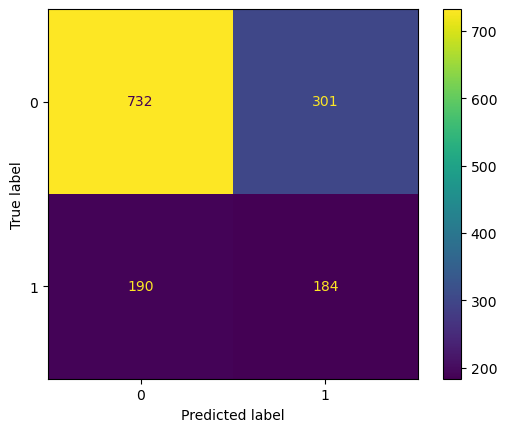

In [56]:
ConfusionMatrixDisplay.from_estimator(model_reg, X_test, y_test);

In [57]:
depth = model_over.named_steps['decisiontreeclassifier'].get_depth()
depth

30

## Communicate

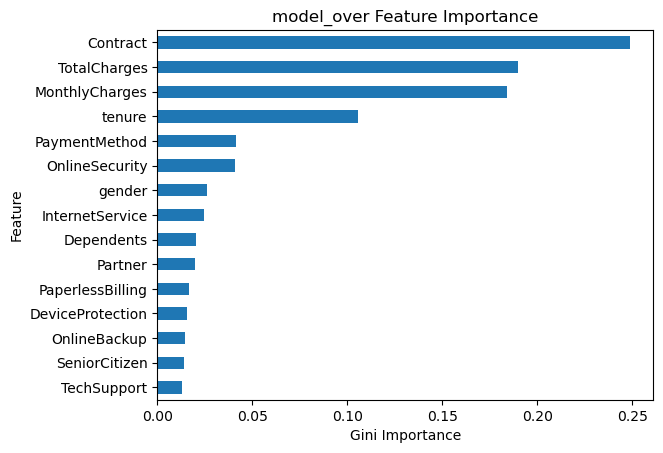

In [58]:
# Get importances

importances = model_over.named_steps['decisiontreeclassifier'].feature_importances_

# Put importances into a Series
feat_imp = pd.Series(importances,index=X_train_over.columns).sort_values()
# Plot series
feat_imp.tail(15).plot(kind="barh")

plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("model_over Feature Importance");

## save model

In [59]:
import pickle

# Save your model as `"model-5-2.pkl"`
with open("model-5-2.pkl","wb") as f:
    pickle.dump(model_over, f)

In [60]:
# Load `"model-5-2.pkl"`
with open("model-5-2.pkl","rb") as f:
    loaded_model = pickle.load(f)
print(loaded_model)

Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])


## Random Forest model

In [61]:
clf = make_pipeline(
    OrdinalEncoder( handle_unknown="use_encoded_value", unknown_value=-1),
    RandomForestClassifier(random_state=42)
)
print(clf)

Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])


In [62]:
cv_acc_scores = cross_val_score(clf, X_train_over, y_train_over, cv=5, n_jobs=-1)
print(cv_acc_scores)

[0.85472155 0.88377724 0.88256659 0.89709443 0.90133172]


In [63]:
params = {
    "randomforestclassifier__n_estimators": range(25, 100, 25),
    "randomforestclassifier__max_depth": range(10, 50, 10),
}
params

{'randomforestclassifier__n_estimators': range(25, 100, 25),
 'randomforestclassifier__max_depth': range(10, 50, 10)}

### grid search.

In [64]:
RFmodel = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
RFmodel.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 50, 10), 'randomforestclassifier__n_estimators': range(25, 100, 25)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [65]:
cv_results = pd.DataFrame(RFmodel.cv_results_)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.432396,0.186154,0.036569,0.011255,10,25,"{'randomforestclassifier__max_depth': 10, 'ran...",0.760000,0.783111,0.771556,0.774222,0.782222,0.774222,0.008395,7
1,0.995091,0.222869,0.070202,0.008049,10,50,"{'randomforestclassifier__max_depth': 10, 'ran...",0.783111,0.787556,0.763556,0.782222,0.791111,0.781511,0.009531,2
2,1.142085,0.248230,0.066503,0.009093,10,75,"{'randomforestclassifier__max_depth': 10, 'ran...",0.777778,0.790222,0.768889,0.790222,0.792000,0.783822,0.009037,1
3,0.704919,0.310635,0.054831,0.005861,20,25,"{'randomforestclassifier__max_depth': 20, 'ran...",0.746667,0.770667,0.762667,0.787556,0.780444,0.769600,0.014249,10
4,1.174930,0.234676,0.091115,0.018771,20,50,"{'randomforestclassifier__max_depth': 20, 'ran...",0.759111,0.769778,0.764444,0.790222,0.788444,0.774400,0.012663,6
5,1.395514,0.252650,0.125020,0.107263,20,75,"{'randomforestclassifier__max_depth': 20, 'ran...",0.758222,0.779556,0.763556,0.791111,0.791111,0.776711,0.013695,5
6,0.391518,0.024111,0.037759,0.003511,30,25,"{'randomforestclassifier__max_depth': 30, 'ran...",0.741333,0.770667,0.742222,0.784889,0.786667,0.765156,0.019879,12
7,1.066657,0.284315,0.144549,0.060481,30,50,"{'randomforestclassifier__max_depth': 30, 'ran...",0.769778,0.766222,0.754667,0.788444,0.785778,0.772978,0.012603,8
8,1.727338,0.212505,0.114812,0.041563,30,75,"{'randomforestclassifier__max_depth': 30, 'ran...",0.762667,0.784000,0.763556,0.788444,0.788444,0.777422,0.011800,4
9,0.757316,0.323726,0.066399,0.024311,40,25,"{'randomforestclassifier__max_depth': 40, 'ran...",0.743111,0.770667,0.742222,0.784889,0.786667,0.765511,0.019462,11


In [66]:
cv_results["param_randomforestclassifier__max_depth"]

0     10
1     10
2     10
3     20
4     20
5     20
6     30
7     30
8     30
9     40
10    40
11    40
Name: param_randomforestclassifier__max_depth, dtype: int32

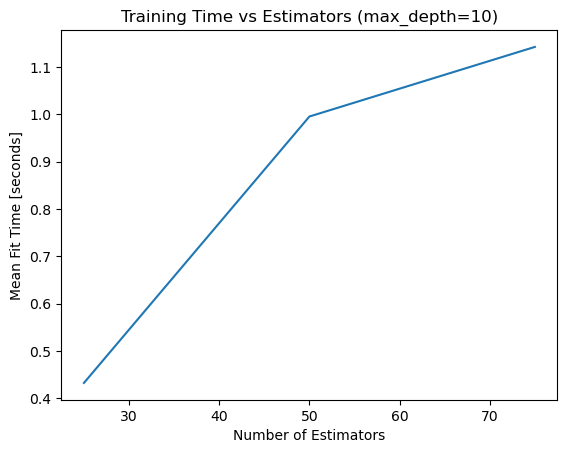

In [67]:
# Create mask
mask = cv_results["param_randomforestclassifier__max_depth"] == 10
# Plot fit time vs n_estimators
plt.plot(
    cv_results[mask]["param_randomforestclassifier__n_estimators"],
    cv_results[mask]["mean_fit_time"]
)
# Label axes
plt.xlabel("Number of Estimators")
plt.ylabel("Mean Fit Time [seconds]")
plt.title("Training Time vs Estimators (max_depth=10)");

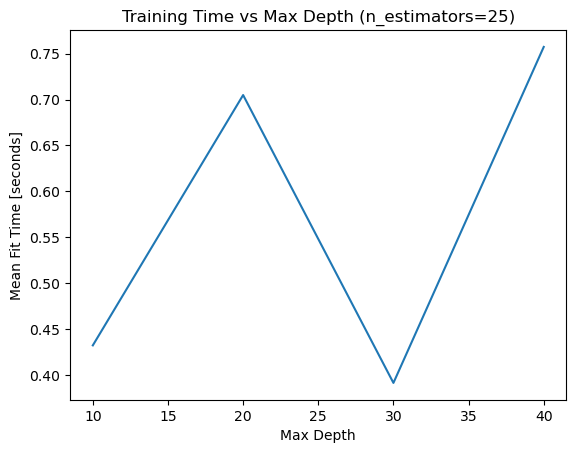

In [68]:
# Create mask

mask = cv_results['param_randomforestclassifier__n_estimators']==25
# Plot fit time vs max_depth
plt.plot(
    cv_results[mask]['param_randomforestclassifier__max_depth'],
    cv_results[mask]['mean_fit_time']
)

# Label axes
plt.xlabel("Max Depth")
plt.ylabel("Mean Fit Time [seconds]")
plt.title("Training Time vs Max Depth (n_estimators=25)");

In [69]:
RFmodel.best_params_

{'randomforestclassifier__max_depth': 10,
 'randomforestclassifier__n_estimators': 75}

In [70]:
acc_train = RFmodel.score(X_train,y_train)
acc_test = RFmodel.score(X_test,y_test)

print("Training Accuracy:", round(acc_train, 4))
print("Test Accuracy:", round(acc_test, 4))

Training Accuracy: 0.8907
Test Accuracy: 0.764


In [71]:
y_test.value_counts()

Churn
0    1033
1     374
Name: count, dtype: int64

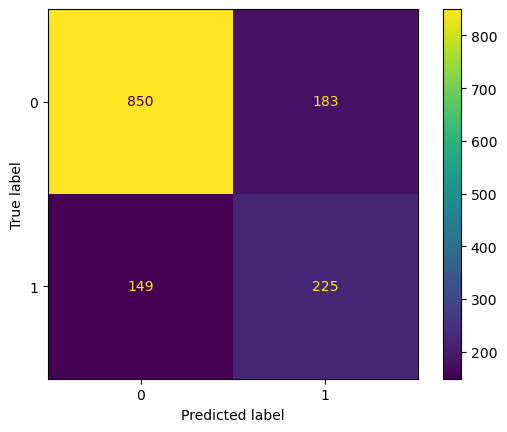

In [72]:
ConfusionMatrixDisplay.from_estimator(RFmodel,X_test,y_test);

### Communicate

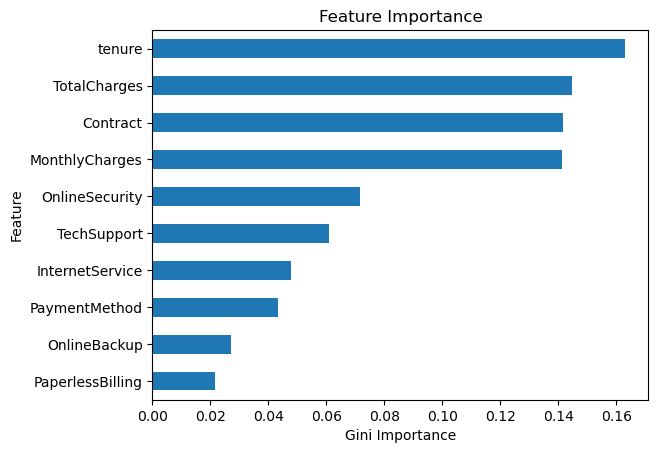

In [73]:
# Get feature names from training data
features = X_train.columns
# Extract importances from model
importances = RFmodel.best_estimator_.named_steps['randomforestclassifier'].feature_importances_
# Create a series with feature names and importances
feat_imp = pd.Series(importances, index=features).sort_values()
# Plot 10 most important features
feat_imp.tail(10).plot(kind="barh")

plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance");

In [74]:
# Save model
with open("model-5-3.pkl","wb") as f:
    pickle.dump(RFmodel, f)
    

In [76]:
'''y_test_pred = make_predictions(
    data_filepath=...,
    model_filepath="model-5-3.pkl",
)

print("predictions shape:", y_test_pred.shape)
y_test_pred.head()
'''

'y_test_pred = make_predictions(\n    data_filepath=...,\n    model_filepath="model-5-3.pkl",\n)\n\nprint("predictions shape:", y_test_pred.shape)\ny_test_pred.head()\n'

## Gradient boosting

In [ ]:
clf = make_pipeline(
    OrdinalEncoder( handle_unknown="use_encoded_value", unknown_value=-1),
    GradientBoostingClassifier())

In [ ]:
params = {
    "gradientboostingclassifier__n_estimators": range(20,31,5) ,
    "gradientboostingclassifier__max_depth": range(2,5)
    }
params

{'gradientboostingclassifier__n_estimators': range(20, 31, 5),
 'gradientboostingclassifier__max_depth': range(2, 5)}

In [ ]:
GBmodel = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=True
)
# Fit model to training data
GBmodel.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 50, 10), 'randomforestclassifier__n_estimators': range(25, 100, 25)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [ ]:
results = pd.DataFrame(GBmodel.cv_results_)
results.sort_values("rank_test_score").head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,1.880349,0.700511,0.095160,0.019416,10,75,"{'randomforestclassifier__max_depth': 10, 'ran...",0.777778,0.790222,0.768889,0.790222,0.792000,0.783822,0.009037,1
1,0.864779,0.068646,0.078193,0.019770,10,50,"{'randomforestclassifier__max_depth': 10, 'ran...",0.783111,0.787556,0.763556,0.782222,0.791111,0.781511,0.009531,2
11,1.077217,0.099500,0.048957,0.014020,40,75,"{'randomforestclassifier__max_depth': 40, 'ran...",0.763556,0.784000,0.763556,0.788444,0.788444,0.777600,0.011582,3
8,1.303965,0.152445,0.087611,0.020470,30,75,"{'randomforestclassifier__max_depth': 30, 'ran...",0.762667,0.784000,0.763556,0.788444,0.788444,0.777422,0.011800,4
5,1.832633,0.326322,0.093545,0.017387,20,75,"{'randomforestclassifier__max_depth': 20, 'ran...",0.758222,0.779556,0.763556,0.791111,0.791111,0.776711,0.013695,5
4,1.686723,0.600662,0.091088,0.022065,20,50,"{'randomforestclassifier__max_depth': 20, 'ran...",0.759111,0.769778,0.764444,0.790222,0.788444,0.774400,0.012663,6
0,0.585870,0.048269,0.047435,0.010353,10,25,"{'randomforestclassifier__max_depth': 10, 'ran...",0.760000,0.783111,0.771556,0.774222,0.782222,0.774222,0.008395,7
7,1.199667,0.232020,0.074559,0.017155,30,50,"{'randomforestclassifier__max_depth': 30, 'ran...",0.769778,0.766222,0.754667,0.788444,0.785778,0.772978,0.012603,8
10,0.837607,0.106864,0.054142,0.004851,40,50,"{'randomforestclassifier__max_depth': 40, 'ran...",0.768889,0.766222,0.754667,0.788444,0.785778,0.772800,0.012653,9
3,0.665844,0.269172,0.052399,0.003503,20,25,"{'randomforestclassifier__max_depth': 20, 'ran...",0.746667,0.770667,0.762667,0.787556,0.780444,0.769600,0.014249,10


In [ ]:
GBmodel.best_params_

{'randomforestclassifier__max_depth': 10,
 'randomforestclassifier__n_estimators': 75}

In [ ]:
acc_train = GBmodel.score(X_train, y_train)
acc_test = GBmodel.score(X_test, y_test)

print("Training Accuracy:", round(acc_train, 4))
print("Validation Accuracy:", round(acc_test, 4))

Training Accuracy: 0.8907
Validation Accuracy: 0.764


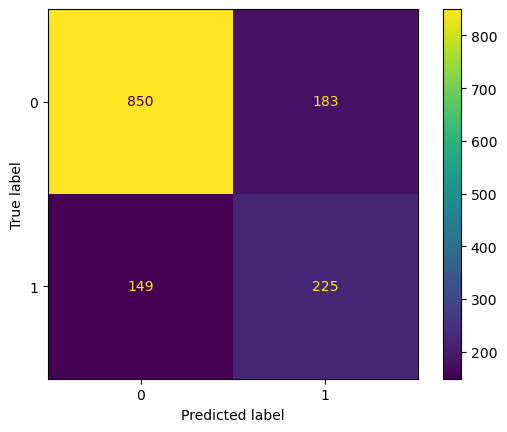

In [ ]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(GBmodel,X_test,y_test);

In [ ]:
y_test.value_counts()

Churn
0    1033
1     374
Name: count, dtype: int64

In [ ]:
# Print classification report
print(classification_report(y_test, GBmodel.predict(X_test)))  

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1033
           1       0.55      0.60      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.76      0.77      1407



In [83]:
import ipywidgets as widgets
from ipywidgets import interact
def make_cnf_matrix(threshold):
    y_pred_propa = GBmodel.predict_proba(X_test)[:,-1 ]
    y_pred = y_pred_propa > threshold
    conf_matrix = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


thresh_widget = widgets.FloatSlider(min=0, max=1, value=0.5, step=0.05)

interact(make_cnf_matrix, threshold=thresh_widget);

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.05), Output()), _dom_cla…